# Week 3 Lab: Vector Data Exploration in Python
## ESCI 3515: Geospatial Artificial Intelligence

---

**Goal for this notebook:**
By the end of this lab, you will be able to:
- Create a GeoDataFrame from scratch using real coordinates
- Inspect geometry types, coordinate reference systems (CRS), and attribute tables
- Filter geographic features by attribute (just like filtering a spreadsheet)
- Make a basic map in Python

**How to use this notebook:**
1. Read each markdown cell (the gray/white text boxes) carefully before running code.
2. Run each code cell in order by clicking on it and pressing **Shift + Enter**.
3. Where you see `# TODO`, that is your turn to write code.
4. If a cell produces an error, read the error message — it usually tells you exactly what went wrong.

**Time estimate:** 60–90 minutes

---
*ESCI 3515 | Module 2 | Week 3*

## Part 1: What is Vector Data?

Spatial data comes in two fundamental forms: **vector** and **raster**.

- **Raster data** divides the world into a regular grid of cells (pixels), each storing a value. Think of a satellite photo or a temperature map.
- **Vector data** represents the world using discrete geometric shapes with exact coordinates.

Vector data has three geometry types:

| Geometry | What it represents | Memphis example |
|----------|--------------------|-----------------|
| **Point** | A single location (x, y) | Fire station, school, hospital |
| **Line** | A path or network | Road, river, power line |
| **Polygon** | An enclosed area | Census tract, neighborhood, park boundary |

In this notebook we will work with **point** and **polygon** data using real Memphis locations.

> **Key idea:** Every vector feature has two parts — a **geometry** (the shape and location) and **attributes** (descriptive data stored in columns, just like a spreadsheet row).

In [1]:
# Cell 3: Check that required libraries are installed
# Run this first — if you see an ImportError, follow the instructions printed below.

try:
    import geopandas
    print(f"GeoPandas is installed: version {geopandas.__version__}")
except ImportError:
    print("GeoPandas is NOT installed.")
    print("To install, open a terminal and run:")
    print("    pip install geopandas")
    print("Then restart this notebook kernel and re-run from Cell 1.")

try:
    import shapely
    print(f"Shapely is installed:   version {shapely.__version__}")
except ImportError:
    print("Shapely is NOT installed. Run: pip install shapely")

try:
    import matplotlib
    print(f"Matplotlib is installed: version {matplotlib.__version__}")
except ImportError:
    print("Matplotlib is NOT installed. Run: pip install matplotlib")

GeoPandas is installed: version 1.1.4
Shapely is installed:   version 2.1.2
Matplotlib is installed: version 3.10.0


In [2]:
# Cell 4: Import all libraries we will use in this notebook
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, box

# Print version numbers so you can confirm your environment
print("Library versions loaded successfully:")
print(f"  GeoPandas : {gpd.__version__}")
print(f"  Pandas    : {pd.__version__}")
print(f"  Matplotlib: {plt.matplotlib.__version__}")

Library versions loaded successfully:
  GeoPandas : 1.1.4
  Pandas    : 2.2.3
  Matplotlib: 3.10.0


## Part 2: Loading Vector Data

In GIS desktop software (like ArcGIS or QGIS), you drag a file onto the map. In Python, we use **GeoPandas** to load data programmatically.

### GeoDataFrame vs. DataFrame
You already met `pandas.DataFrame` in Module 1 — a table of rows and columns. A **GeoDataFrame** is a special kind of DataFrame that has one extra column called `geometry`. That column holds the actual shapes (points, lines, polygons) for each row.

```
Regular DataFrame:
   name         type
0  Shelby Farms Park    park
1  Central Library      library

GeoDataFrame (adds geometry):
   name                 type      geometry
0  Shelby Farms Park    park      POINT (-89.8725 35.1315)
1  Central Library      library   POINT (-90.0490 35.1456)
```

### Common vector file formats

| Format | Extension | Notes |
|--------|-----------|-------|
| **Shapefile** | `.shp` (+ `.dbf`, `.shx`, `.prj`) | Oldest standard; still very common |
| **GeoJSON** | `.geojson` or `.json` | Human-readable text; great for sharing online |
| **GeoPackage** | `.gpkg` | Modern, single-file format; supports multiple layers |
| **KML** | `.kml` | Google Earth format |

For this notebook, we will **create a GeoDataFrame from scratch** using raw coordinates — the same technique you will use whenever you receive a CSV file with latitude/longitude columns.

In [3]:
# Cell 6: Create a GeoDataFrame of Memphis landmarks from scratch
# We start with a regular Python dictionary of data.

data = {
    "name": [
        "Shelby Farms Park",
        "Memphis Public Library (Central)",
        "St. Jude Children's Research Hospital",
        "University of Memphis",
        "Overton Park",
        "Germantown High School",
        "Methodist Le Bonheur Hospital",
        "Memphis Botanic Garden",
        "Benjamin L. Hooks Central Library",
        "Trezevant High School"
    ],
    "type": [
        "park", "library", "hospital", "school",
        "park", "school", "hospital", "park",
        "library", "school"
    ],
    "lat": [
        35.1315, 35.1456, 35.1498, 35.1186,
        35.1469, 35.0867, 35.1502, 35.1156,
        35.1456, 35.1839
    ],
    "lon": [
        -89.8725, -90.0490, -90.0354, -89.9368,
        -89.9841, -89.8101, -90.0393, -89.9290,
        -90.0490, -89.9686
    ]
}

# Step 1: Create a regular pandas DataFrame
df = pd.DataFrame(data)

# Step 2: Convert to GeoDataFrame using lat/lon columns
# gpd.points_from_xy() turns separate lon/lat columns into Point geometry objects
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"   # WGS84 — the standard lat/lon coordinate system
)

# Step 3: Inspect the result
print("Shape (rows, columns):", gdf.shape)
print()
print("First five rows:")
print(gdf.head())
print()
print("Column names:", list(gdf.columns))
print()
print("Coordinate Reference System:", gdf.crs)

Shape (rows, columns): (10, 5)

First five rows:
                                    name      type      lat      lon  \
0                      Shelby Farms Park      park  35.1315 -89.8725   
1       Memphis Public Library (Central)   library  35.1456 -90.0490   
2  St. Jude Children's Research Hospital  hospital  35.1498 -90.0354   
3                  University of Memphis    school  35.1186 -89.9368   
4                           Overton Park      park  35.1469 -89.9841   

                   geometry  
0  POINT (-89.8725 35.1315)  
1   POINT (-90.049 35.1456)  
2  POINT (-90.0354 35.1498)  
3  POINT (-89.9368 35.1186)  
4  POINT (-89.9841 35.1469)  

Column names: ['name', 'type', 'lat', 'lon', 'geometry']

Coordinate Reference System: EPSG:4326


### What did we just create?

Let's break down the output from Cell 6:

- **Shape (10, 5)** — 10 rows (features), 5 columns (name, type, lat, lon, geometry)
- **geometry column** — Each row has a `POINT (-89.xxxx 35.xxxx)` value. This is a Shapely `Point` object storing longitude first, then latitude.
- **CRS: EPSG:4326** — This tells GeoPandas that our coordinates are in degrees of longitude and latitude using the WGS84 datum (the same system used by GPS).

> **Why longitude first?** This trips up beginners! In math and GIS, coordinates are (x, y) = (east-west, north-south) = (longitude, latitude). But when we *describe* a location to a person, we usually say "latitude, longitude" (north-south first). GeoPandas follows the mathematical convention: lon first, lat second.

The `CRS` (Coordinate Reference System) is like a rulebook that says: "these numbers mean *this* location on Earth." We will go deep on CRS in Week 4.

In [4]:
# Cell 8: Explore the geometry properties of our GeoDataFrame

# 1. Count geometry types
print("Geometry type counts:")
print(gdf.geometry.geom_type.value_counts())
print()

# 2. Print the CRS in detail
print("Full CRS description:")
print(gdf.crs)
print()

# 3. Print the bounding box: (min_lon, min_lat, max_lon, max_lat)
bounds = gdf.total_bounds
print("Bounding box of all features:")
print(f"  West  (min lon): {bounds[0]:.4f}")
print(f"  South (min lat): {bounds[1]:.4f}")
print(f"  East  (max lon): {bounds[2]:.4f}")
print(f"  North (max lat): {bounds[3]:.4f}")
print()

# 4. Show individual geometry objects
print("First 3 geometry objects:")
for i, row in gdf.head(3).iterrows():
    print(f"  {row['name']}: {row.geometry}")

Geometry type counts:
Point    10
Name: count, dtype: int64

Full CRS description:
EPSG:4326

Bounding box of all features:
  West  (min lon): -90.0490
  South (min lat): 35.0867
  East  (max lon): -89.8101
  North (max lat): 35.1839

First 3 geometry objects:
  Shelby Farms Park: POINT (-89.8725 35.1315)
  Memphis Public Library (Central): POINT (-90.049 35.1456)
  St. Jude Children's Research Hospital: POINT (-90.0354 35.1498)


## Part 3: Filtering and Selecting Features

One of the most useful things you can do with a GeoDataFrame is **filter** it — keep only the rows that meet some condition.

This works exactly the same as filtering a pandas DataFrame. You write a condition inside square brackets:

```python
# General pattern:
filtered_gdf = gdf[gdf["column_name"] == "some_value"]

# Example:
parks_gdf = gdf[gdf["type"] == "park"]
```

The condition `gdf["type"] == "park"` produces a list of `True` / `False` values (one per row). GeoPandas keeps only the rows where the value is `True`.

This is called **boolean indexing** — the same technique you learned in Module 1 with pandas, now applied to spatial data.

> **Tip:** You can combine conditions with `&` (and) or `|` (or):
> ```python
> health_sites = gdf[(gdf["type"] == "hospital") | (gdf["type"] == "library")]
> ```

In [5]:
# Cell 10: Filter to only parks
parks_gdf = gdf[gdf["type"] == "park"]

print(f"Total features in original GeoDataFrame: {len(gdf)}")
print(f"Features after filtering to 'park' only: {len(parks_gdf)}")
print()
print("Parks in our dataset:")
print(parks_gdf[["name", "type", "lat", "lon"]])

Total features in original GeoDataFrame: 10
Features after filtering to 'park' only: 3

Parks in our dataset:
                     name  type      lat      lon
0       Shelby Farms Park  park  35.1315 -89.8725
4            Overton Park  park  35.1469 -89.9841
7  Memphis Botanic Garden  park  35.1156 -89.9290


In [6]:
# Cell 11: TODO — Your turn!
# Filter the GeoDataFrame to show only schools.
# 1. Create a variable called schools_gdf containing only rows where type == 'school'
# 2. Print how many schools there are
# 3. Print the names of the schools

# YOUR CODE HERE:
schools_gdf = gdf[gdf["type"] == "school"]   # filter step
print(f"Number of schools: {len(schools_gdf)}")
print()
print("Schools in our dataset:")
print(schools_gdf[["name", "type"]])

# Bonus: try filtering to hospitals and print their names too

Number of schools: 3

Schools in our dataset:
                     name    type
3   University of Memphis  school
5  Germantown High School  school
9   Trezevant High School  school


## Part 4: Creating Polygon Data

So far we have worked with **points** (single locations). Many GIS analyses also require **polygons** — shapes that enclose an area.

Common polygon datasets include:
- **Census tracts** — areas used by the US Census Bureau to report demographic data
- **Neighborhoods** — official or informal district boundaries
- **Parcel data** — individual property boundaries
- **Flood zones** — FEMA-defined risk areas

In this section, we will create simple rectangular bounding-box polygons for three Memphis neighborhoods using `shapely.geometry.box()`.

```python
# shapely.geometry.box(min_lon, min_lat, max_lon, max_lat)
# This creates a rectangle (Polygon) from corner coordinates.
```

In real work, you would load these polygons from a Shapefile or GeoJSON provided by the city or the Census Bureau — but building them manually first helps you understand the underlying structure.

In [7]:
# Cell 13: Create a polygon GeoDataFrame representing Memphis neighborhood bounding boxes
# We use shapely.geometry.box() to create simple rectangular polygons.
# box(min_lon, min_lat, max_lon, max_lat)

neighborhood_data = {
    "neighborhood": ["Midtown", "Downtown", "East Memphis"],
    "population":   [28500,     22000,      41000],
    "geometry": [
        box(-90.0200, 35.1300, -89.9700, 35.1600),   # Midtown approximate bbox
        box(-90.0700, 35.1350, -90.0200, 35.1550),   # Downtown approximate bbox
        box(-89.9700, 35.0900, -89.8800, 35.1500),   # East Memphis approximate bbox
    ]
}

neighborhoods_gdf = gpd.GeoDataFrame(neighborhood_data, crs="EPSG:4326")

print("Neighborhood polygons:")
print(neighborhoods_gdf)
print()
print("Geometry type:", neighborhoods_gdf.geometry.geom_type.values)
print("CRS:", neighborhoods_gdf.crs)
print()
print("Bounding box of neighborhoods layer:")
print(neighborhoods_gdf.total_bounds)

Neighborhood polygons:
   neighborhood  population                                           geometry
0       Midtown       28500  POLYGON ((-89.97 35.13, -89.97 35.16, -90.02 3...
1      Downtown       22000  POLYGON ((-90.02 35.135, -90.02 35.155, -90.07...
2  East Memphis       41000  POLYGON ((-89.88 35.09, -89.88 35.15, -89.97 3...

Geometry type: ['Polygon' 'Polygon' 'Polygon']
CRS: EPSG:4326

Bounding box of neighborhoods layer:
[-90.07  35.09 -89.88  35.16]


## Part 5: Basic Mapping

Now that we have spatial data loaded, let's make a map.

GeoPandas has a built-in `.plot()` method that works with **matplotlib** — the same plotting library you used in Module 1.

The basic pattern is:

```python
fig, ax = plt.subplots(figsize=(10, 8))   # create a blank figure
gdf.plot(ax=ax)                            # draw the GeoDataFrame on that figure
plt.title("My Map Title")                  # add a title
plt.show()                                 # display the map
```

**Key `.plot()` arguments:**

| Argument | What it does |
|----------|--------------|
| `color` | Single color for all features (e.g., `"blue"`) |
| `column` | Column name — colors each feature by that column's value |
| `cmap` | Colormap to use (e.g., `"Set1"`, `"viridis"`, `"Reds"`) |
| `legend=True` | Add a legend |
| `markersize` | Size of point markers |
| `edgecolor` | Color of polygon borders |

> **Note:** At this stage we are making simple, coordinate-only maps — no basemap background. In Week 4 we will add basemap tiles using the `contextily` library.

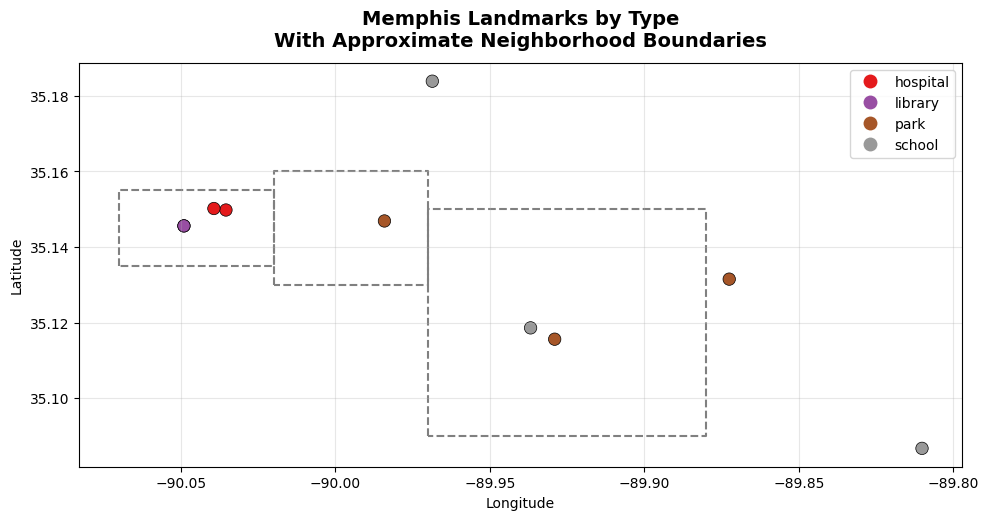

Map rendered successfully.


In [8]:
# Cell 15: Plot the Memphis landmarks, colored by type
fig, ax = plt.subplots(figsize=(10, 8))

# Color each point by its 'type' column using a categorical colormap
gdf.plot(
    ax=ax,
    column="type",
    cmap="Set1",
    legend=True,
    markersize=80,
    edgecolor="black",
    linewidth=0.5
)

# Also overlay the neighborhood polygons as transparent outlines
neighborhoods_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=1.5,
    linestyle="--",
    label="Neighborhoods (bounding boxes)"
)

# Labels and formatting
ax.set_title("Memphis Landmarks by Type\nWith Approximate Neighborhood Boundaries",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Map rendered successfully.")

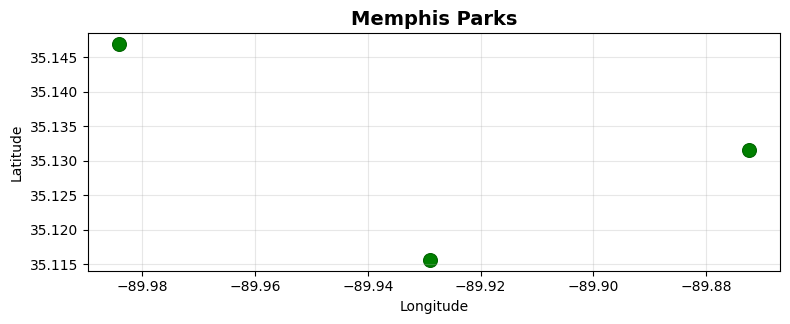

In [9]:
# Cell 16: TODO — Your turn!
# Create a map showing ONLY the parks (use the parks_gdf you created in Cell 10).
# Requirements:
#   - Use color='green'
#   - Use markersize=100
#   - Add a descriptive title
#   - Add axis labels (xlabel and ylabel)
#   - Call plt.show() at the end

# YOUR CODE HERE:
fig, ax = plt.subplots(figsize=(8, 7))

parks_gdf.plot(
    ax=ax,
    color="green",
    markersize=100,
    edgecolor="darkgreen",
    linewidth=0.8
)

ax.set_title("Memphis Parks", fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6: Saving Your Work

Once you have created or processed a GeoDataFrame, you will want to save it so you can reuse it in other notebooks or share it.

The `.to_file()` method saves a GeoDataFrame to disk. You specify the file path and the driver (format):

```python
# Save as GeoJSON (human-readable, good for sharing)
gdf.to_file("my_data.geojson", driver="GeoJSON")

# Save as GeoPackage (efficient, good for multiple layers)
gdf.to_file("my_project.gpkg", driver="GPKG")

# Save as Shapefile (older format, still widely used)
gdf.to_file("my_data.shp")   # driver="ESRI Shapefile" is the default
```

**For this course** we will primarily use GeoJSON (easy to inspect and share) and GeoPackage (efficient for larger datasets).

> **Important:** Make sure the directory you are saving to already exists. Python will raise a `FileNotFoundError` if the folder does not exist. Use `os.makedirs(folder, exist_ok=True)` to create it safely.

In [10]:
# Cell 18: Save our GeoDataFrame as a GeoJSON file
import os

# Make sure the output directory exists
output_dir = "/tmp/geoai_week3_output"
os.makedirs(output_dir, exist_ok=True)

# Save the full landmarks GeoDataFrame
output_path = f"{output_dir}/memphis_sample_points.geojson"
gdf.to_file(output_path, driver="GeoJSON")
print(f"Saved: {output_path}")

# Also save the parks subset
parks_output = f"{output_dir}/memphis_parks.geojson"
parks_gdf.to_file(parks_output, driver="GeoJSON")
print(f"Saved: {parks_output}")

# Confirm the files exist and check their sizes
for path in [output_path, parks_output]:
    size_kb = os.path.getsize(path) / 1024
    print(f"  {os.path.basename(path)}: {size_kb:.1f} KB")

print()
print("To reload this file in a new notebook:")
print(f"  gdf = gpd.read_file('{output_path}')")

Saved: /tmp/geoai_week3_output/memphis_sample_points.geojson
Saved: /tmp/geoai_week3_output/memphis_parks.geojson
  memphis_sample_points.geojson: 2.1 KB
  memphis_parks.geojson: 0.7 KB

To reload this file in a new notebook:
  gdf = gpd.read_file('/tmp/geoai_week3_output/memphis_sample_points.geojson')


## Week 3 Reflection — Discussion Board Post

Before you post to the Discussion Board, use this checklist to make sure your reflection covers the required content.

**Your reflection should address:**

- [ ] **Dataset identified** — Name a specific geospatial dataset used in Memphis city planning, public health, or transportation. Examples: Memphis Light Gas & Water parcel data, Shelby County Health Department facility locations, TDOT road network, Memphis Area Transit Authority (MATA) routes.

- [ ] **Data model identified** — State whether it is vector (and if so, what geometry type: point, line, or polygon) or raster (and if so, what the grid values represent).

- [ ] **At least two spatial questions** — Describe two specific questions you could answer using that dataset. Example: "How many residents live within a 10-minute walk of a MATA bus stop?"

- [ ] **One limitation or challenge** — Identify one realistic challenge you might face using that dataset (missing data, outdated records, CRS mismatch with another layer, etc.).

**Response length:** 150–250 words is ideal. Quality over quantity.

---

### Quick vocabulary review before Quiz 2

| Term | Definition |
|------|-----------|
| Vector data | Spatial data using points, lines, or polygons |
| Raster data | Spatial data as a grid of cells/pixels |
| GeoDataFrame | A pandas DataFrame with a geometry column |
| CRS | Coordinate Reference System — the rulebook for interpreting coordinates |
| EPSG code | A numeric ID for a specific CRS (e.g., EPSG:4326 = WGS84) |
| Attribute table | The non-spatial columns of a GeoDataFrame |
| Bounding box | The rectangle that encloses all features in a layer |

---
*End of Week 3 Lab Notebook | ESCI 3515 Module 2*